Упражнение 1

In [3]:

import matplotlib.pyplot as plt

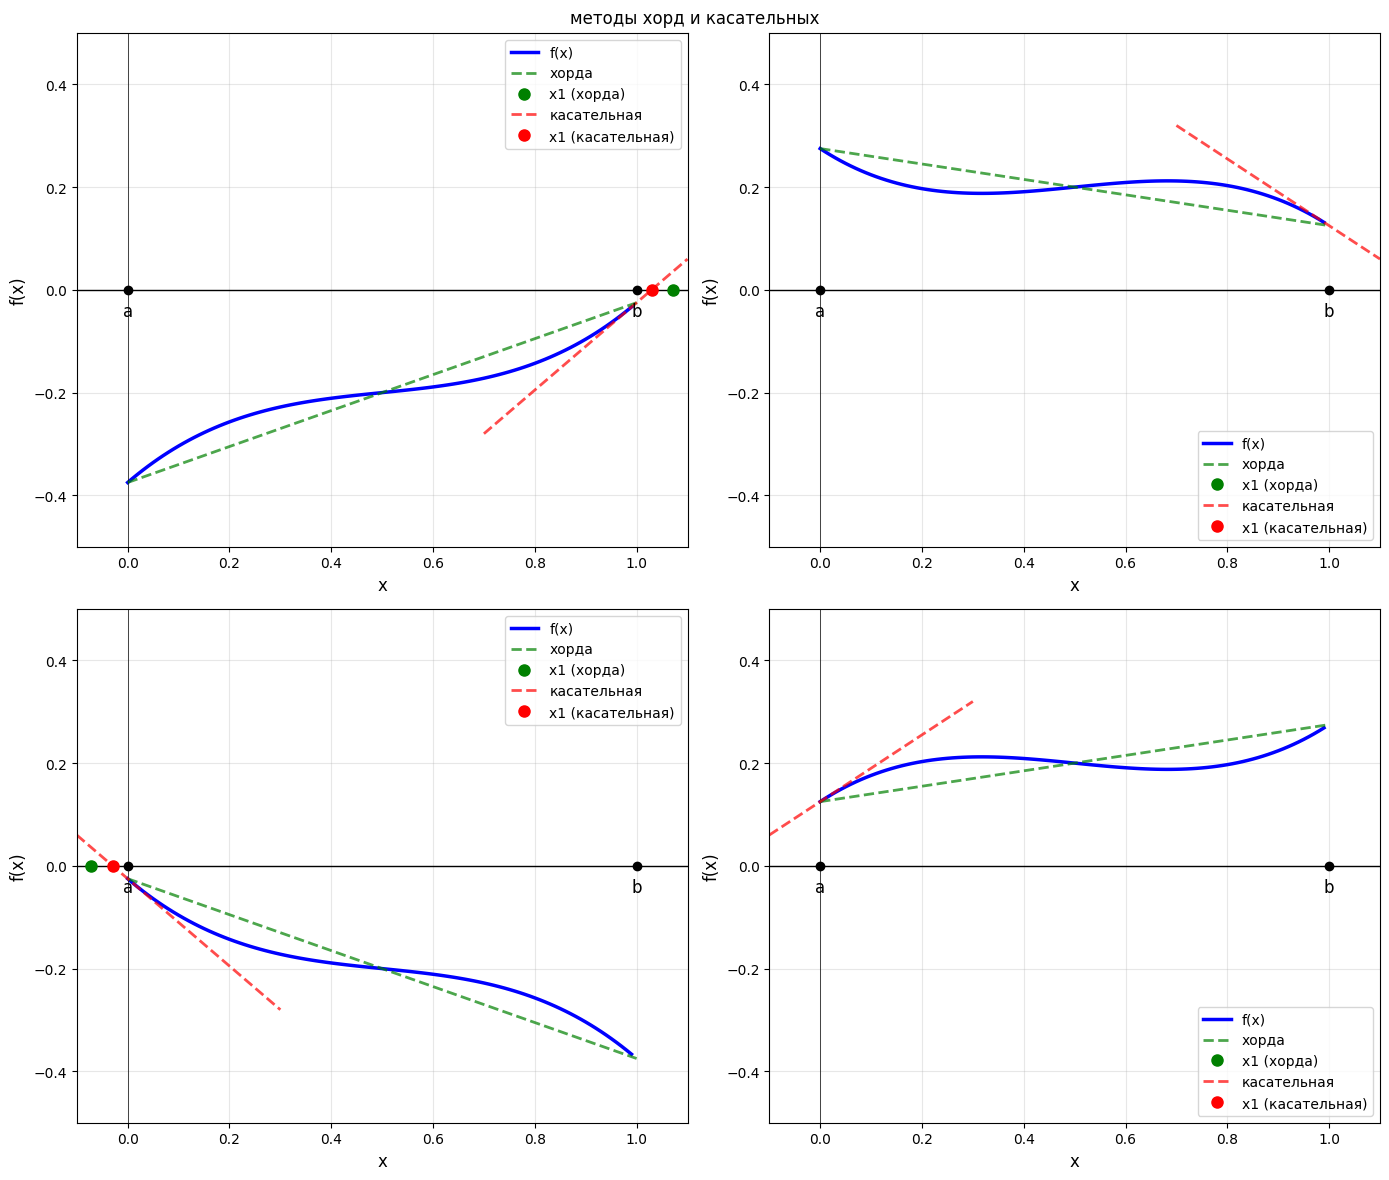

In [4]:
# определяем четыре функции
def gr1(x):
    return (x - 0.5)**3 + 0.1*(x - 0.5) - 0.2

def gr2(x):
    return -((x - 0.5)**3) + 0.1*(x - 0.5) + 0.2

def gr3(x):
    return -((x - 0.5)**3) - 0.1*(x - 0.5) - 0.2

def gr4(x):
    return (x - 0.5)**3 - 0.1*(x - 0.5) + 0.2

cases = [gr1, gr2, gr3, gr4]

# создаем 4 графика (2x2)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

# для каждого случая
for i, func in enumerate(cases):
    ax = axes[i]
    
    # создаем точки для графика функции от 0 до 1 с шагом 0.01
    x_vals = []
    y_vals = []
    x = 0
    while x <= 1:
        x_vals.append(x)
        y_vals.append(func(x))
        x += 0.01
    
    # рисуем график функции
    ax.plot(x_vals, y_vals, 'b-', linewidth=2.5, label='f(x)')
    
    # оси
    ax.axhline(0, color='black', linewidth=1)  # ось x
    ax.axvline(0, color='black', linewidth=0.5)  # ось y
    
    # отмечаем границы отрезка [a, b]
    a, b = 0, 1
    ax.plot([a, b], [0, 0], 'ko', markersize=6)
    ax.text(a, -0.05, 'a', fontsize=12, ha='center')
    ax.text(b, -0.05, 'b', fontsize=12, ha='center')
    
    # ищем корень (где функция меняет знак)
    for j in range(len(y_vals)-1):
        if y_vals[j] * y_vals[j+1] <= 0:
            root_x = (x_vals[j] + x_vals[j+1]) / 2
            root_y = func(root_x)
            ax.plot(root_x, root_y, 'k*', markersize=12, label='корень')
            break
    
    # метод хорд - первое приближение
    x_chord1 = a - func(a) * (b - a) / (func(b) - func(a))
    # рисуем хорду
    ax.plot([a, b], [func(a), func(b)], 'g--', linewidth=2, alpha=0.7, label='хорда')
    ax.plot(x_chord1, 0, 'go', markersize=8, label='x1 (хорда)')
    
    # метод касательных
    h = 0.00001  # маленькое число для производной
    
    if i < 2:  # для первых двух случаев касательная от b
        # производная в точке b
        df_b = (func(b + h) - func(b - h)) / (2*h)
        x_tang1 = b - func(b) / df_b
        
        # рисуем касательную
        x_tan = [b-0.3, b+0.1]
        y_tan = [func(b) + df_b * (x - b) for x in x_tan]
        ax.plot(x_tan, y_tan, 'r--', linewidth=2, alpha=0.7, label='касательная')
        ax.plot(x_tang1, 0, 'ro', markersize=8, label='x1 (касательная)')
        
    else:  # для последних двух касательная от a
        # производная в точке a
        df_a = (func(a + h) - func(a - h)) / (2*h)
        x_tang1 = a - func(a) / df_a
        
        # рисуем касательную
        x_tan = [a-0.1, a+0.3]
        y_tan = [func(a) + df_a * (x - a) for x in x_tan]
        ax.plot(x_tan, y_tan, 'r--', linewidth=2, alpha=0.7, label='касательная')
        ax.plot(x_tang1, 0, 'ro', markersize=8, label='x1 (касательная)')
    
    # настройки графика
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('f(x)', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.5, 0.5)

# общий заголовок
plt.suptitle('методы хорд и касательных')
plt.tight_layout()
plt.show()

Упражнение 2

In [ ]:
def f(x):
    # функция f(x)
    return x**3 + 3*x**2 - 24*x + 1

def df(x):
    # производная функции f'(x)
    return 3*x**2 + 6*x - 24

# комбинированный метод хорд и касательных
def comb(a, b, eps):
    n = 1  # счетчик итераций
    
    while True:
        # значения функции на концах отрезка
        fa, fb = f(a), f(b)
        # значения производной на концах отрезка
        dfb = df(b)
        # x - метод хорд
        x = a - fa * (b - a) / (fb - fa)
        
        # y - метод касательных
        y = b - fb / dfb
        
        # выводим информацию об итерации
        print(f"Итерация {n}: x = {x:.6f}, y = {y:.6f}, f(x) = {f(x):.6f}, f(y) = {f(y):.6f}")
        
        # проверка точности, если прошла - заканчиваем цикл выводом значения
        if abs(f(x)) < eps and abs(f(y)) < eps:
            # берем среднее арифметическое как корень
            root = (x + y) / 2
            print(f"Корень найден на итерации {n}: {root:.6f}")
            return root
        
        # проверка - корень между x и y
        if f(x) * f(y) < 0:
            # да - сужаем отрезок до [x, y]
            a, b = min(x, y), max(x, y)
        else:
            # нет - выбираем новую границу
            if abs(x - b) < abs(y - a):
                b = x  # заменяем правую границу
            else:
                a = y  # заменяем левую границу
        
        n += 1  # увеличиваем счетчик

# вывод метода на отрезке 0, 1 с заданной точностью
root = comb(0, 1, 0.000001)

Итерация 1: x = 0.050000, y = -0.266667, f(x) = -0.192375, f(y) = 7.594370
Итерация 2: x = 0.042177, y = 0.041880, f(x) = -0.006827, f(y) = 0.000207
Итерация 3: x = 0.041889, y = 0.041889, f(x) = -0.000000, f(y) = 0.000000
Корень найден на итерации 3: 0.041889
